In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from math import *

import matplotlib.animation as animation
from IPython.display import HTML

# 1. Red light, green light (8 points)

In this problem, we will consider the behavior of traffic on a stretch of road $x\in[-1,1]$ due to a traffic light at $x=1$.
![](traffic.png)

1. Consider the 1D LWR traffic model with car density $q\in[0,1]$ and max car speed $u_\text{max}=1$, traffic flow velocity $u(q)=1-q \in[0,1]$, and the flux $f(q)=q(1-q)$. What is the analytical expression for the characteristic velocity $c(q)$ for this model? For what values of $q$ is the characteristic velocity negative?

2. Consider the discretization
    \begin{gather*}
    \frac{Q_j^{n+1}-Q_j^n}{\Delta{t}} + \frac{F^n_{j+\frac{1}{2}}-F^n_{j-\frac{1}{2}}}{\Delta{x}} = 0 \\
    F^n_{j+\frac{1}{2}}=U^n_{j+\frac{1}{2}}Q^n_{j+\frac{1}{2}},\quad F^n_{j-\frac{1}{2}}=U^n_{j-\frac{1}{2}}Q^n_{j-\frac{1}{2}}
    \end{gather*}
                
    Here, we've defined the numerical approximations
    \begin{gather*}
        F^n_{j+\frac{1}{2}} = f(x_{j+\frac{1}{2}},t_n) \qquad U^n_{j+\frac{1}{2}} = u(x_{j+\frac{1}{2}},t_n) \qquad Q^n_{j+\frac{1}{2}} = q(x_{j+\frac{1}{2}},t_n) \\
    x_{j+\frac{1}{2}}=-1+\big(j+\frac{1}{2}\big)\Delta{x} \qquad t_n=n\Delta{t}
    \end{gather*}
    
    Show that the first equation can be rewritten as
$$ \frac{Q_j^{n+1}-Q_j^n}{\Delta{t}} + C^n_j\frac{Q^n_{j+\frac{1}{2}}-Q^n_{j-\frac{1}{2}}}{\Delta{x}} = 0 $$
    where the discrete characteristic velocity is
$$ C^n_j=1-Q^n_{j+\frac{1}{2}}-Q^n_{j-\frac{1}{2}} $$

3. Implement the WENO scheme discussed in class to solve for the density in time using the discretization in found in the previous part. Discretize the domain $x\in[-1,1]$ by $m=201$ evenly-spaced points with spacing $\Delta{x}=2/(m-1)$. Use a timestep of $\Delta{t}=0.001$ and integrate to a final time $T=1.5$, outputting $150$ snapshots after the initial state ($151$ outputs total). As initial conditions, use the step function
$$ Q^0_j = \begin{cases}
    q_l, & x<0    \\
    q_r, & x\geq0
  \end{cases} $$
    for fixed values $q_l$ and $q_r$. When the interpolant for $Q^n_{j+\frac{1}{2}}$ or $Q^n_{j-\frac{1}{2}}$ relies on points outside the domain, use the ghost node approach and treat the density on these nodes as fixed at $q_l$ on the left and $q_r$ on the right, respectively.

    At each grid cell, the sign of the characteristic velocity $C^n_j$ must be determined to select the appropriate upwind condition. At the start of the step, compute the intermediate value
$$ \widehat{C_j}^n = 1-Q^n_{j+1}-Q^n_{j-1} $$
    from known values $Q^n_{j+1}$ and $Q^n_{j-1}$, and use its sign to select the proper set of upwind interpolants and compute $Q^n_{j+\frac{1}{2}}$ and $Q^n_{j-\frac{1}{2}}$. Then compute the final characteristic velocity $C^n_j$ and use it in the update rule given. 
    
    You can consult [this Jupyter notebook](https://github.com/chr1shr/am205_g_activities/blob/master/eno_methods/lin_adv_eno_solutions.ipynb) for implementing the WENO scheme, but note that the notations for density and velocity is different.

    Run your program for the following two cases: 
    1. **Red light**: $q_l=0.4, q_r=1.0$. Physically, we imagine that the traffic light at $x=1$ is red, and the traffic is initially backed up and standing still from $[0,1]$ while more vehicles approach from the left.
    2. **Green light**: $q_l=1.0, q_r=0.4$. Now, the light at $x=1$ is green, and traffic on $[0,1]$ has reduced, while cars on $[-1,0]$ are initially still at rest.
    
    For each case, plot snapshots of the density at the four times $t=0,0.5,1,1.5$.

### Part 1

The characteristic velocity is the deriative of the flux, so
$$ c(q) = f'(q) = 1 - 2q $$ 

From this, we see that the characteristic velocity is negative if $q > 1/2$.

### Part 2

We just need to verify
\begin{align*}
    C_j^n \left( Q_{j+1/2}^n - Q_{j-1/2}^n \right) &= \left( 1 - Q^n_{j+1/2} - Q^n_{j-1/2} \right) \left( Q_{j+1/2}^n - Q_{j-1/2}^n \right) \\
    &= Q_{j+1/2}^n - Q_{j-1/2}^n - \left( Q_{j+1/2}^n \right)^2 + \left( Q_{j-1/2}^n \right)^2 \\
    &= Q_{j+1/2}^n \left(1 - Q_{j+1/2}^n \right) - Q_{j-1/2}^n \left( 1 - Q_{j-1/2}^n \right) \\
    &= U^n_{j+1/2} Q^n_{j+1/2} - U^n_{j-1/2} Q^n_{j-1/2} \\
    &= F^n_{j+1/2} - F^n_{j-1/2}
\end{align*}

since $U_j^n = 1 - Q_j^n$. Thus we obtain the desired equation.

### Part 3

In [ ]:
# Stencil stuff
stencil_coeffs = np.array([[3./8, -10./8, 15./8, 0, 0],
                         [0, -1./8, 6./8, 3./8, 0],
                         [0, 0, 3./8, 6./8, -1./8]])

beta_coeffs = np.array([[4./3, -19./3, 25./3, 11./3, -31./3, 10./3],
                      [4./3, -13./3, 13./3, 5./3, -13./3, 4./3],
                      [10./3, -31./3, 25./3, 11./3, -19./3, 4./3]])

# Grid + ghost node setup
m = 201 
mp6 = m + 6

# PDE-related constants
c = 1.
dx = 2.0/(m-1)
dt = 0.001
nu = c * dt/dx

T = 1.
snaps = 150
iters = int(T/dt) // snaps

# Compute the smoothness indicator \beta^(k)
def smoothness(k, Ql, Qc, Qr):
    c = beta_coeffs[k]
    Fs = np.array([Ql**2, Ql*Qc, Qc**2, Ql*Qr, Qc*Qr, Qr**2])
    return np.dot(c, Fs)

# TODO: add weights
def weno_step(Q, i)
    Qs = np.array(Q[i-2], Q[i-1], Q[i], Q[i+1], Q[i+2])
    beta = np.zeros(3)
    for k in range(3):
        beta[k] = smoothness(k, Qs[k], Qs[k+1], Qs[k+2])
    c = stencil_coeffs[np.argmin(beta)]  # optimal scheme
    return np.dot(c, us)

def weno(ql, qr):
    u = np.empty(mp6) # memory for the current step
    u1 = np.empty(mp6) # memory for the next step
    us = np.empty((m, snaps+1)) # memory for all snapshots

    # TODO: modify this
    # Initial condition
    xs = [-1 + i*dx for i in range(m)]
    k=100
    for j in range(-3,m+3,1): # include ghost nodes
        x=-1+dx*j
        u[j]= 1./(1+np.exp(-k*x))

    u1=np.copy(u)
    us[:,0]=u[:m]

    for i in range(1, snaps + 1):
        for k in range(iters):
            for j in range(m):
                  ur = weno_step(u[j-2],u[j-1],u[j],u[j+1],u[j+2]) # u_j+1/2
                  ul = weno_step(u[j-3],u[j-2],u[j-1],u[j],u[j+1]) # u_j-1/2
                  u1[j] = u[j] - nu * (ur - ul)
            u = np.copy(u1)
        us[:,i] = u[:m]


In [4]:
# Plotting code
def plot_wave(x, y, ax):
      line, = ax.plot(x, y, color='C0')
      return line
    
def update_line(line, x, y):
      line.set_data(x, y)

def animate_wave(x,z):
    # each column of z represents a frame.
    fig, ax = plt.subplots(1, 1, figsize=(12,6))
    ax.plot(x,z[:,0], linestyle='dashed', color='C0') # initial state.
    line = plot_wave(x, z[:,0], ax)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel('x')
    ax.set_ylabel('q')

    def animate(i):
        fr = i
        line.set_data(x, z[:,i])
        return line,

    ani = animation.FuncAnimation(fig, animate, frames=z.shape[1], interval=100, blit=True)
    plt.close(fig)
    return ani

x=np.linspace(-1, 1, m)
ani = animate_wave(x, us)
HTML(ani.to_html5_video())

# 2. Primers on spectral methods (6 points)

1. Consider the infinite grid $h\mathbb{Z}$ with $h=1$. By considering the second derivative of the constant function $v(x)=1$ on $h\mathbb{Z}$, show that
$$ \frac{\pi^2}{12} = 1 - \frac{1}{2^2} + \frac{1}{3^2} - \frac{1}{4^2} + \ldots $$

2. Consider the function $v(x)=\sin \tfrac{\pi x}{2}$ on the infinite grid $h\mathbb{Z}$ with $h=1$. Introduce the function
$$ p_\alpha(x) = \sum_{m=-\alpha}^\alpha v_m S_h(x-x_m) $$
    where $S_h$ is the sinc function introduced in the lectures, $x_m=mh$, and $v_m=v(x_m)$. Write a program to compute $E_\alpha=\|p_\alpha - v\|_2$ over the range $[-5,5]$ for $\alpha=1,2,4,8,\ldots,512$. Fit the data to a power law
$$  E_\alpha = C \alpha^q $$
    and determine the parameters $C$ and $q$. (You will need to use numerical integration to do this. You can use a library function, trapezoid rule, or other quadrature rule.)
    
3. The band-limited interpolant is $p(x) = \lim_{\alpha\to \infty} p_\alpha(x)$. Part (2) shows that $E_\alpha \to 0$ as $\alpha \to \infty$, and hence $p(x)=v(x)$. Explain from the theory of band-limited interpolants why this must be the case. It may be helpful to know that the Fourier transform of $e^{i\lambda x}$ is $\delta(k-\lambda)$ where $\delta$ is the Dirac delta function.

4. By considering the first derivative of $v$ from part (b), show that
$$ \frac{\pi}{4} = 1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + \ldots $$

5. By using an appropriate function choice, show that
$$ \frac{\pi^2}{6} = 1 + \frac{1}{2^2} + \frac{1}{3^2} + \frac{1}{4^2} + \ldots $$

### Part 1

Consider the constant function $v(x) = 1$, then the semidiscrete Fourier transform is
$$ \hat u(k) = \sum_{j=-\infty}^\infty e^{-ik j} $$

The interpolant is
\begin{align*}
    p(x) &= \frac{1}{2\pi} \int_{-\pi}^\pi e^{ikx} \sum_{j=-\infty}^\infty e^{-ik j} dk \\
    &= \sum_{j=-\infty}^\infty \frac{\sin(\pi(x - j)}{\pi(x - j)}
\end{align*}

Note that in the limit $x \to j$, we get
$$ \frac{\sin(\pi(x-j))}{\pi(x - j)} \to 1$$
so the interpolant can be written as
$$ p(x) = \sum_{j=-\infty}^\infty \text{sinc}(\pi(x - j)) = \sum_{j=-\infty}^\infty S_1(x - j) $$

Taking the derivative twice gives
$$ p''(0) = -\frac{\pi^2}{3} + \sum_{j \neq 0} 2 \frac{(-1)^{j+1}}{j^2} = 0 $$

Note that the sum can be rewritten as
\begin{align*}
    \frac{(-1)^{j+1}}{j^2} &= \sum_{j > 0} \frac{(-1)^{-j+1}}{(-j)^2} + \frac{(-1)^{j+1}}{j^2} \\
    &= \sum_{j > 0} \frac{(-1)^{j+1 - 2j}}{j^2} + \frac{(-1)^{j+1}}{j^2} \\
    &= 2 \sum_{j > 0} \frac{(-1)^{j+1}}{j^2}
\end{align*}

Thus we get that
\begin{gather*}
    4\left( 1 - \frac{1}{2^2} + \frac{1}{3^2} - \cdots \right) &= \frac{\pi^2}{3} \\
    1 - \frac{1}{2^2} + \frac{1}{3^2} - \cdots = \frac{\pi^2}{12}
\end{gather*}
as desired.

### Part 2


C=2.34	 q=-1.24


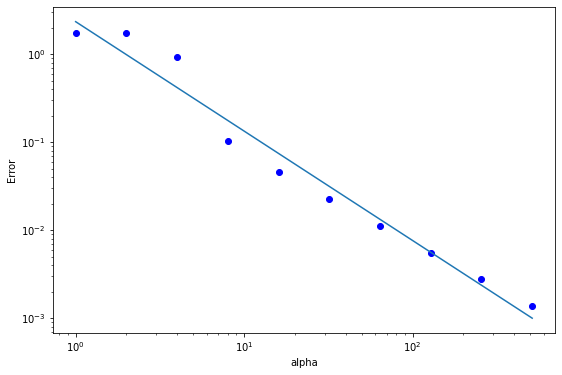

In [2]:
def v(x):
    return np.sin(np.pi * x/2)

def pa(x, alpha):
    ms = np.arange(-alpha, alpha + 1)
    vs = [v(m) for m in ms]
    sincs = np.sinc(x - ms)
    return np.sum(vs * sincs)

def integrand(x, alpha):
    return np.abs(v(x) - pa(x, alpha))**2

alphas = [2**x for x in range(10)]
errs = []

for alpha in alphas:
    errs.append(np.sqrt(quad(lambda x: integrand(x, alpha), -5, 5)[0]))
    
A = np.asmatrix([[np.log(alpha), 1] for alpha in alphas])
q, C = np.linalg.lstsq(A, np.log(errs), rcond=None)[0]

C = np.exp(C)
fit = [C * alpha**q for alpha in alphas]
print(f"\nC={C:.3}\t q={q:.3}")

plt.figure(figsize=(9,6))
plt.loglog(alphas, errs, 'bo')
plt.loglog(alphas, fit)
plt.xlabel("alpha")
plt.ylabel("Error")
plt.show()

### Part 3

### Part 4

The semidiscrete Fourier transform is
$$ \hat u(k) = \sum_{j = -\infty}^\infty e^{-ikj} \sin\left(\frac{\pi j}{2}\right) = \sum_{j=-\infty}^\infty e^{-ik(2j+1)} (-1)^j $$

Proceeding in the same was as part 1, we find that the interpolant is
$$ p(x) = \frac{1}{2\pi} \sum_{j=-\infty}^\infty \int_{-\pi}^\pi (-1)^j e^{ik(x - 2j - 1)} dk = \sum_{j=-\infty}^\infty (-1)^j S_1(x - 2j - 1) $$

and the derivative is
$$ p'(0) = \sum_{j=-\infty}^\infty (-1)^j\frac{(-1)^{2j+1}}{2j + 1} = \sum_{j=-\infty}^\infty \frac{(-1)^{j+1}}{2j + 1} = v'(0) = \frac{\pi}{2} $$

Expanding the sum we see that it's twice the desired sum so
$$ 1 - \frac{1}{3} + \frac{1}{5} - \cdots = \frac{\pi}{4} $$
as desired.

### Part 5

To obtain the $\pi^2$ we want to take a second derivative based on our result in part a. Furthermore we need a nonvanishing second derivative at grid points, so a good choice is $v(x) = \cos(\pi x)$. Proceeding as before, we obtain
\begin{gather*}
    \hat u(k) = \sum_{j=-\infty}^\infty (-1)^j e^{-ikj} \\
    p(x) = \sum_{j=-\infty}^\infty (-1)^j S_1(x-j)
\end{gather*}

Taking the second derivative gives
$$ p''(0) = -\frac{\pi^2}{3} - \sum_{j \neq 0} \frac{2}{j^2} = v''(0) = -\pi^2 $$

By symmetry, the sum is 4 times the desired sum, so we find that 
\begin{gather*}
    4\left( 1 + \frac{1}{2^2} + \frac{1}{3^2} + \cdots \right) = \frac{2\pi^2}{3} \\
    1 + \frac{1}{2^2} + \frac{1}{3^2} + \cdots = \frac{\pi^2}{6}
\end{gather*}
as desired.

# 3. Chebyshev spectral method (6 points).

Consider the boundary value problem
$$ u_{xx} + u^5 = f $$
for the function $u(x)$ on the non-periodic interval $[-1,1]$, with a source term $f(x)$. Use the Dirichlet conditions $u(-1)=u(1)=0$. Write  a program that can find $u$ represented on a Chebyshev grid with $N+1$ grid points. Since  the BVP is nonlinear, you will need to solve this using the Newton method. (This is similar to Question 3 on Homework 1)

1. Use the method of manufactured solutions, with the solution
$$ u(x)=e^x(x^2-1) $$
    Calculate what $f$ will be in order for $u$ to satify the BVP.
2. For a range of $N$ from 4 to 64, calculate the numerical solution $p_N(x)$ to the BVP. Start your Newton method from the function $(x+1)^2(x-1)$ as an initial guess. Make a semilog plot of $\|p_N-u\|_2$ as a function of $N$.

### Part 1

Using the given solution, we have
\begin{align*}
    u_x &= e^x(x^2 - 1) + 2xe^x = e^x(x^2 + 2x - 1) \\
    u_{xx} &= e^x(x^2 + 2x - 1) + e^x(2x + 2) \\
    &= e^x(x^2 + 4x + 1)
\end{align*}

so we want
$$ f = e^x(x^2 + 4x + 1) + e^{5x}(x^2 - 1)^5 $$

### Part 2


Let $D_N$ be the Chebyshev differentiation matrix and $U_i = u(x_i)$ the approximation of the solution at the $i$-th Chebyshev grid point $i = 0,1,\ldots,N$. Let $f_i = f(x_i)$, then we are trying to solve the system
$$ \tilde{D_N}^2 \begin{pmatrix}
u_1 \\ u_2 \\ \vdots \\ u_{N-1}
\end{pmatrix} + \begin{pmatrix}
u_1^5 \\ u_2^5 \\ \vdots \\ u_{N-1}^5
\end{pmatrix} - \begin{pmatrix}
f_1 \\ f_2 \\ \vdots \\ f_{N-1}
\end{pmatrix} = 0$$
where we note (from lecture) that the first and last rows and columns can be ignored, so $\tilde D_N$ is the internal part of the $D_n$. To use Newton's method, we need an expression for the Jacobian. Since the first term is linear, we get
$$ J = \tilde{D_N}^2 + \begin{pmatrix}
5u_1^4 \\ & 5u_2^4 \\ && \ddots \\ &&& 5u_{N-1}^4
\end{pmatrix}$$

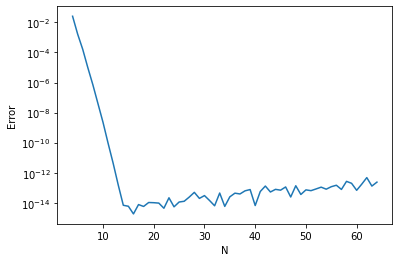

In [15]:
def u(x):
    return np.exp(x) * (x**2 - 1)

def f(x):
    return np.exp(x) * (x**2 + 4*x + 1) + np.exp(5*x) * (x**2 - 1)**5

def cheb(N):
    xs = np.cos(np.linspace(0, np.pi, N+1))
    c = np.ones((N + 1))
    c[0] = 2
    c[N] = 2
    
    D = np.empty((N + 1, N + 1))
    D[0,0] = (2 * N**2 + 1) / 6
    for i in range(1, N):
        D[i,i] = -xs[i] / (2 * (1 - xs[i]**2))
    D[N,N] = -D[0,0]
    
    for i in range(N + 1):
        for j in range(N + 1):
            if i != j:
                D[i,j] = c[i] * (-1)**(i+j) / (c[j] * (xs[i] - xs[j]))
    return (xs, D)

def compute_sol(N):
    # Get Chebyshev differentiation matrix
    xs, D = cheb(N)
    D2 = D @ D
    D2_tilde = D2[1:N, 1:N]
    fs = f(xs)[1:N]

    # Run Newton's method with provided initial guess
    p = np.array([(x+1)**2 * (x-1) for x in xs[1:N]])
    p_norm = 0
    dp_norm = 0
    idx = 0
    while dp_norm == 0 or dp_norm / p_norm > 1e-10:
        Fs = D2_tilde.dot(p) + p**5 - fs
        J = D2_tilde + np.diag(5 * p**4)
        delta_p = np.linalg.solve(J, -Fs)
        
        p += delta_p
        dp_norm = np.linalg.norm(delta_p)
        p_norm = np.linalg.norm(p)
        
    exact = u(xs)[1:N]
    return (p, np.linalg.norm(p - exact))

Ns = np.arange(4, 65)
errs = []
for N in Ns:
    p, err = compute_sol(N)
    errs.append(err)

plt.semilogy(Ns, errs)
plt.xlabel("N")
plt.ylabel("Error")
plt.show()